# Diabetes Readmission Analysis

## Importing libraries

In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

import os
os.makedirs('/content/drive/MyDrive/portfolio projects/Diabetes 130 US hospitals for years 1999-2008/data/visuals', exist_ok=True)

## Data Loading

In [2]:
#!rm -rf /content/drive

In [3]:
# Mounting Google Drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/portfolio projects/Diabetes 130 US hospitals for years 1999-2008/data/diabetic_data.csv')

Mounted at /content/drive


## General Data Cleaning

In [4]:
# Checking for missing values and duplicates.
df.isna().sum()
df.duplicated().sum()

np.int64(0)

In [5]:
# No duplicate encounters (encounter_id is unique)
#30,248 duplicate patient_nbr — same patient may appear multiple times across different hospitalizations

In [6]:
# Replacing '?' placeholders with NaN
df = df.replace('?', np.nan)

In [7]:
# Creating binary target variable readmitted_group: patients readmitted within 30 days → 1, all others → 0.
conditions = [
    df['readmitted'] == '<30',
    df['readmitted'] != '<30'
]

choices = [
    1,
    0
]

df.loc[:, 'readmitted_group'] = np.select(conditions, choices, default=np.nan)

## Hypothesis 1: Impact of Medication Change on Readmission
### Patients whose diabetes treatment regimen was modified during hospitalization (dose increased/decreased or a new drug added, e.g., insulin) have a higher 30-day readmission rate (readmitted < 30) than patients whose therapy remained stable.


In [8]:
# Сreating clear df for h1
df_h1 = df[['change', 'readmitted_group']].copy()

In [9]:
df_h1['change'].unique()

array(['No', 'Ch'], dtype=object)

In [10]:
# Сreating patients groups - who got changed therapy  - 1, who didn't - 0
conditions = [
    df_h1['change'] == 'Ch',
    df_h1['change'] != 'Ch'
]

choices = [
    1,
    0
]

df_h1.loc[:, 'change_group'] = np.select(conditions, choices, default=np.nan)

In [11]:
df_h1['change_group'].isna().sum()

np.int64(0)

In [12]:
df_h1.groupby('change_group')['readmitted_group'].mean()
readmission_rates = df_h1.groupby('change_group')['readmitted_group'].mean() * 100

In [13]:
# Build contingency table
table = pd.crosstab(df_h1['change_group'], df_h1['readmitted_group'])

# Chi-square test for statistical significance
stat, p, dof, expected = chi2_contingency(table)

print(f"p-value: {p}")

p-value: 5.212417406066974e-10


In [14]:
# xi- test for categorical data
stat, p, dof, expected = chi2_contingency(table)

print(f"p-value: {p}")
# p = 5.21e-10 < 0.05 — difference between groups is statistically significant

p-value: 5.212417406066974e-10


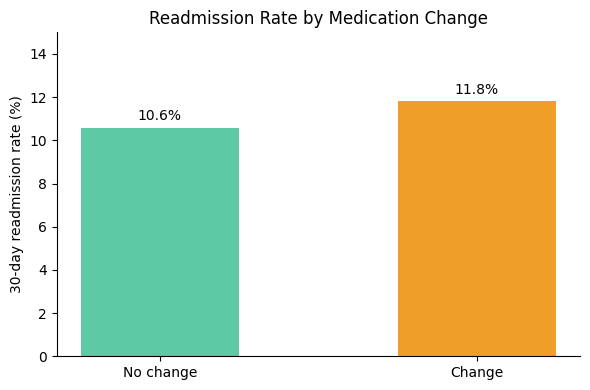

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No change', 'Change'], readmission_rates,
               color=['#5DCAA5', '#EF9F27'], width=0.5)

ax.set_ylim(0, 15)
ax.set_ylabel('30-day readmission rate (%)')
ax.set_title('Readmission Rate by Medication Change')
ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/portfolio projects/Diabetes 130 US hospitals for years 1999-2008/data/visuals/h1_readmission_by_change.png', dpi=150)
plt.show()

## Conclusion
Statistical analysis confirms a significant association between treatment change and 30-day readmission rate (p < 0.001).  Patients whose therapy was adjusted during hospitalization showed a higher readmission rate compared to those on stable treatment — 11.8% vs. 10.6%, a difference of 1.2 percentage points.
## Limitations
* ​Disease Severity: A change in therapy is often a marker that a patient’s condition is unstable or decompensated. Therefore, higher readmission rates may be a consequence of the severity of the disease rather than the fact of the medication change itself.
* ​Lack of Confounding Control: The analysis does not take into account the number of previous hospitalizations, age, or the presence of comorbidities (e.g., cardiovascular disease), which also affect the risk of relapse.
* ​Direction of Change: The data do not specify whether the change in therapy was an intensification (addition of medication) or a simplification (withdrawal), which has different clinical implications.

## Recommendations
* ​Stratified Analysis: Conduct additional analysis by dividing patients by number of diagnoses or length of hospital stay to test whether this effect holds for patients with the same severity of condition.
​* Enhanced Monitoring: For patients whose therapy was changed during hospitalization, it is recommended to implement enhanced outpatient monitoring or a follow-up call in the first 7–14 days after discharge.

## Hypothesis 2: Role of HbA1c Monitoring
Patients who did not receive an HbA1c test during hospitalization (A1Cresult = None) have a higher 30-day readmission rate than those who were tested — regardless of the result (>8, >7, or Normal).

In [16]:
# Сreating clear df for h2
df_h2 = df[['readmitted_group', 'A1Cresult']].copy()

In [17]:
# Creating binary group: tested (1) vs. not tested (0)
conditions = [
    df_h2['A1Cresult'].notna() == True,
    df_h2['A1Cresult'].isna() == True
]

choices = [
    1,
    0
]

df_h2.loc[:, 'A1Cresult_group'] = np.select(conditions, choices, default=np.nan)

In [18]:
# Compare readmission rates between groups
df_h2.groupby('A1Cresult_group')['readmitted_group'].mean()
readmission_a1_rates = df_h2.groupby('A1Cresult_group')['readmitted_group'].mean() * 100

In [19]:
# Not tested: 11.4% | Tested: 9.8%

In [20]:
# Build contingency table
table2 = pd.crosstab(df_h2['readmitted_group'], df_h2['A1Cresult_group'])

# Chi-square test for statistical significance
stat, p, dof, expected = chi2_contingency(table2)

print(f"p-value: {p}")
# p = 2.83e-09 < 0.05 — difference between groups is statistically significant

p-value: 2.8335168145423924e-09


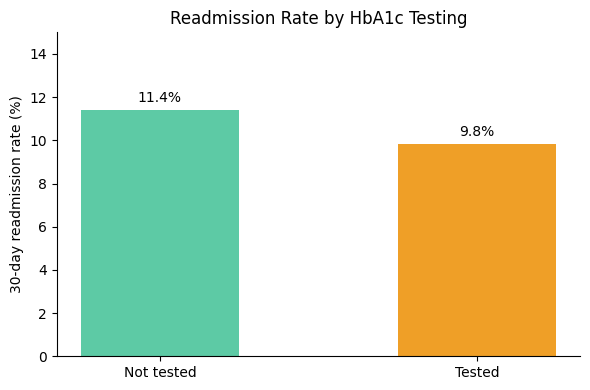

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Not tested', 'Tested'], readmission_a1_rates,
               color=['#5DCAA5', '#EF9F27'], width=0.5)

ax.set_ylim(0, 15)
ax.set_ylabel('30-day readmission rate (%)')
ax.set_title('Readmission Rate by HbA1c Testing')
ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/portfolio projects/Diabetes 130 US hospitals for years 1999-2008/data/visuals/h2_readmission_by_change.png', dpi=150)
plt.show()

## Conclusion
The analysis found that the use of glycated hemoglobin (HbA1c) testing is associated with a lower 30-day readmission rate within 30 days ($p < 0.001$). Patients who had their HbA1c measured during their hospital stay had a lower rate of readmission (9.8%) compared to those who did not have this test (11.4%). This suggests that monitoring glycemic control is a marker of more comprehensive inpatient care.

## Limitations
* Omitted Variable Bias: The use of HbA1c testing may be an indicator of higher overall quality of care at a particular facility or an important physician attitude, rather than a single factor.
* Data Completeness: We compare the "tested" versus "not tested" groups, but do not consider the test result itself (normal or very high), which could provide a deeper understanding of the risks.
* Clinical Context: For treatment, hospitalized for a short period or with acute conditions not related to diabetes, the HbA1c test may be objectively unnecessary, creating a natural selection bias.

## Recommendations  
* Standardization of protocols: It is recommended to include HbA1c measurement in the mandatory hospitalization protocol for all users with the disease "diabetes mellitus" if the test has not been performed in the last 3 months.
* Control analysis: Analyze the group of diseases with high HbA1c levels (>8%) to apply whether they require special programs that support after discharge (e.g., self-monitoring education).
* Resource Allocation: Since testing correlates with better outcomes (lower hospitalization), the cost of mass testing may be economically justified by reducing the cost of repeat hospitalizations.

# Hypothesis 3: Emergency Visit History vs. Length of Current Stay
Patients with a higher number of emergency department visits in the prior year (number_emergency) are more likely to be readmitted within 30 days than those with longer current hospital stays (time_in_hospital).


In [22]:
# Сreating clear df for h3
df_h3 = df[['number_emergency', 'time_in_hospital', 'readmitted_group']].copy()


In [23]:
# Point-biserial correlation: numerical variable vs. binary outcome
# number_emergency vs. readmission
res_emerg = pointbiserialr(df_h3['number_emergency'], df_h3['readmitted_group'])

# time_in_hospital vs. readmission
res_hosp_time = pointbiserialr(df_h3['time_in_hospital'], df_h3['readmitted_group'])

# Отримання результатів
print(f"Correlation with number of emergency: {res_emerg.statistic}")
print(f"P-value: {res_emerg.pvalue}")

print(f"Correlation with time in hospital: {res_hosp_time.statistic}")
print(f"P-value: {res_hosp_time.pvalue}")

# Results:
# number_emergency: r = 0.06, p < 0.001 — weak but significant positive correlation
# time_in_hospital: r = 0.04, p < 0.001 — weaker correlation, less predictive

Correlation with number of emergency: 0.06074650014253612
P-value: 8.29543703716343e-84
Correlation with time in hospital: 0.044199418457447515
P-value: 3.454567874336736e-45


## Conclusion
The analysis confirmed that both the number of emergency visits (number_emergency) and the length of stay in the hospital (time_in_hospital) are positively correlated with the risk of readmission.
* The coefficient for emergency visits (0.06) is higher than that for length of stay (0.04).
* This means that a patient’s history of emergency cases is a stronger indicator of the risk of readmission than the duration of the current hospitalization

## Limitations
* Weak Correlation: Although the relationship is statistically significant due to the large sample size, the coefficients themselves (0.06 and 0.04) are quite low. This indicates that hospitalization depends on a large number of other factors that are not accounted for in this model.
* Outliers: Patients with an abnormally high number of emergency visits or excessively long hospital stays can significantly influence the result of the biserial correlation.
* Nature of Emergency: We do not know the reasons for the emergency visits - whether they were related specifically to diabetic decompensation or to other acute conditions.


## Recommendations
* Early Risk Screening: Patients with a history of two or more emergency visits in the prior year should be flagged at admission for enhanced discharge planning and post-discharge follow-up.
* Investigate Emergency Causes: Linking emergency visit data to diagnosis codes would clarify whether visits were diabetes-related — strengthening the clinical interpretation of this finding.

# Hypothesis 4: Comorbidity — Cardiovascular Disease and Diabetes

Patients whose primary diagnosis (diag_1) falls within cardiovascular ICD-9 codes and whose secondary diagnosis (diag_2 or diag_3) relates to diabetes have a statistically higher 30-day readmission rate compared to patients primarily hospitalized for diabetes-related complications.

In [24]:
# Сreating clear df for h3
df_h4 = df[['diag_1', 'diag_2', 'diag_3', 'readmitted_group']].copy()

In [25]:
# Convert diag_1 to numeric — raw ICD-9 codes are stored as strings
# errors='coerce' converts non-numeric values (e.g. 'E934') to NaN
# diag_1_binary - cardiovasc

df_h4['diag_1'] = pd.to_numeric(df_h4['diag_1'], errors='coerce')

# Flag cardiovascular primary diagnosis (ICD-9: 390–459, 785)
conditions = [
    (df_h4['diag_1'].between(390, 459)) | (df_h4['diag_1'] == 785)
]

choices = [1]

df_h4.loc[:, 'diag_1_binary'] = np.select(conditions, choices, default=0)

In [26]:
# Flag diabetes in secondary diagnosis diag_2 (ICD-9: 250.xx, V58)
conditions2 = [
    df_h4['diag_2'].str.contains('V58|250', na=False)
]

choices = [1]

df_h4.loc[:, 'diag_2_binary'] = np.select(conditions2, choices, default=0)

In [27]:
# Flag diabetes in secondary diagnosis diag_3
conditions3 = [
    df_h4['diag_3'].str.contains('V58|250', na=False)
]

choices = [1]

df_h4.loc[:, 'diag_3_binary'] = np.select(conditions3, choices, default=0)

In [28]:
# Assign patient groups based on diagnosis combination:
# 'cardio-diab' — cardiovascular primary + diabetes secondary
# 'diab'        — diabetes as primary diagnosis (ICD-9: 250.xx)
# 'other'       — all remaining patients
conditions = [
    (df_h4['diag_1_binary'] == 1) & ((df_h4['diag_2_binary'] == 1) | (df_h4['diag_3_binary'] == 1)),
    df_h4['diag_1'].between(250, 250.99, inclusive='both')
]

choices = [
    'cardio-diab',
    'diab'
  ]

df_h4.loc[:, 'group'] = np.select(conditions, choices, default = 'other')

In [29]:
(df_h4['group'].value_counts(normalize = True) * 100).round(2)
# Group distribution:
# other: 82.65% | cardio-diab: 8.74% | diab: 8.61%

,proportion
group,
other,82.65
cardio-diab,8.74
diab,8.61


In [30]:
# Compare readmission rates across groups
rate = (df_h4.groupby('group')['readmitted_group'].mean()*100).round(2)
rate
# cardio-diab: 10.983% | diab: 12.98% | other: 10.99%




,readmitted_group
group,
cardio-diab,10.98
diab,12.98
other,10.99


In [31]:
# Chi-square test on cardio-diab vs. diab only (excluding 'other')
table4 = pd.crosstab(
    df_h4[df_h4['group'] != 'other']['group'],
    df_h4[df_h4['group'] != 'other']['readmitted_group']
)

stat, p, dof, expected = chi2_contingency(table4)

print(f"p-value: {p}")
# p = 4.55e-05 < 0.001 — difference is statistically significant
# H4 is rejected: diabetes-primary patients show higher readmission (12.98%)
# than cardio-diabetic patients (10.98%

p-value: 4.554774267709534e-05


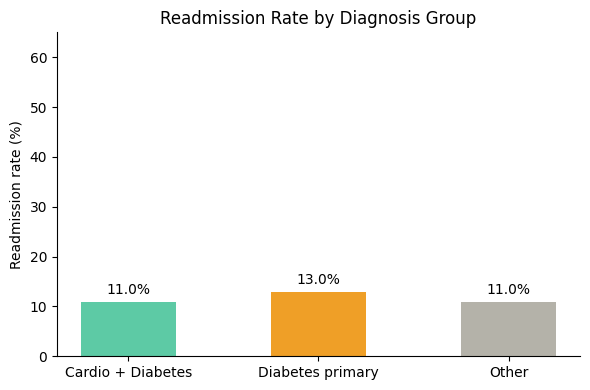

In [32]:
# Readmission rates by diagnosis group
groups = ['Cardio + Diabetes', 'Diabetes primary', 'Other']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, rate,
              color=['#5DCAA5', '#EF9F27', '#B4B2A9'],
              width=0.5)

ax.set_ylim(0, 65)
ax.set_ylabel('Readmission rate (%)')
ax.set_title('Readmission Rate by Diagnosis Group')
ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/portfolio projects/Diabetes 130 US hospitals for years 1999-2008/data/visuals/h4_readmission_by_change.png', dpi=150)
plt.show()

## Conclusion
Statistical analysis rejects the hypothesis that comorbidity (cardiovascular disease + diabetes) leads to a higher incidence of hospitalizations than pure diabetes. The results show that the group with the main diagnosis "Diabetes mellitus" (diab) has a rehospitalization rate of 12.98%, while the group "cardio + diabetes" (cardio-diab) - 10.98%. The difference is statistically significant ($p < 0.001), indicating that decompensation of diabetes as the primary cause of hospitalization is a more critical risk factor for readmission.

## Limitations
* Acute vs. Chronic: Hospitalization with a primary cardiac diagnosis (e.g., myocardial infarction) often ends with radical intervention (stenting), which stabilizes the patient. Instead, hospitalization with primary diabetes often indicates systemic difficulties in managing a chronic condition that do not resolve after discharge.
* Coding Specificity: Using diag_1 as the primary criterion may oversimplify the real clinical picture, where multiple conditions may be equally severe.
* Survival Bias: Patients with severe cardiac conditions have a higher risk of in-hospital mortality, which may artificially lower the rate of readmission compared to the diabetes group.
* Diagnosis Code Specificity: ICD-9 code V58 (encounter for other and unspecified procedures and aftercare) was included as a diabetes indicator alongside code 250.xx. However, V58 is not diabetes-specific and may capture patients receiving aftercare for other conditions, potentially introducing noise into the diabetes group classification.

## Recommendations
Focus on Primary Diabetes:
Patients whose primary reason for hospitalization is diabetes require intensive review of their outpatient treatment plan and Diabetes Self-Management Education, as they are the most vulnerable group for rapid readmission.